# iprPy relax_liquid calculation

In [1]:
# Standard library imports
import datetime

# http://www.numpy.org/
import numpy as np

import matplotlib.pyplot as plt

# https://ipython.org/
from IPython.display import display, Code, Markdown, Pretty

# https://github.com/usnistgov/atomman 
import atomman as am
import atomman.unitconvert as uc

# https://github.com/usnistgov/iprPy
import iprPy

print('Notebook last executed on', datetime.date.today(), 'using iprPy version', iprPy.__version__)

Notebook last executed on 2026-06-30 using iprPy version 0.12.a


## 1. Load calculation and view description

### 1.1. Load the calculation

In [2]:
# Load the calculation being demoed
calculation = iprPy.load_calculation('relax_liquid')

### 1.2. Display calculation description and theory

In [3]:
# Display main docs and theory
display(Markdown(calculation.maindoc))
display(Markdown(calculation.theorydoc))

# relax_liquid calculation style

**Lucas M. Hale**, [lucas.hale@nist.gov](mailto:lucas.hale@nist.gov?Subject=ipr-demo), *Materials Science and Engineering Division, NIST*.

## Introduction

The relax_liquid calculation style is designed to generate a liquid phase configuration for an atomic potential based on an initial configuration, target temperature and target pressure.  The calculation also computes the radial distribution function for the resulting liquid state.

### Version notes

- 2022-10-12: Calculation created
- v0.12.0: Calculation completely reworked and simplified.  Method updated to support the LAMMPS library interface.

### Additional dependencies

### Disclaimers

- [NIST disclaimers](http://www.nist.gov/public_affairs/disclaimer.cfm)
- If starting with a crystalline configuration, be sure to use an adequately high melt temperature and number of melt steps.
- No active checks are performed by this calculation to ensure that the system is liquid. Be sure to check the final atomic configurations.


## Method and Theory

### Simulation runs

This calculation performs up to three MD simulation stages based on the inputs to generate an equilibrium liquid phase

1. Melt stage: MD is performed at an elevated temperature to ensure that a liquid phase is formed.
2. Equilibrium stage: MD is performed at the lower target temperature but no analysis output is generated.
3. Analysis stage: MD continues at the target temperature and thermo data and dump configuration files are generated.

All three stages use the NPT Nose-Hoover style thermostat+barostat with all three box dimensions coupled together. This allows for the system to relax to a target pressure while preventing any of the box dimensions from shrinking too small for the RDF calculations.

Additionally, the calculation supports optionally creating new velocities for all atoms prior to performing MD.  This is useful if starting from an ideal atomic configuration, or for running repeat simulation tests to evaluate the methodology error.

The first two MD stages are optional and can be skipped by specifying 0 steps be performed for either/both stages. Skipping the melt stage is useful if you are starting from a known liquid configuration. Skipping the equilibrium stage is not recommended unless you are starting from a known liquid configuration already equilibrated at the target temperature.

### RDF calculation

The radial distribution function (RDF) for the liquid is computed from the dump files generated during the analysis stage. For each dump file, atomic neighbor lists are constructed for all atoms within a given cutoff distance, and the neighbor list counts are binned based on radial distances. The RDF is then computed by dividing by the expected density of each bin's radial shell based on the ideal bulk density.  To generate smooth curves, the RDF values are averaged across all dump files.

*Note* The RDF calculations are performed using the atomman.thermo.RDF class rather than using the LAMMPS compute rdf option.  This is done as by default the LAMMPS version only allows RDFs out to the potential's cutoff to be computed.  With the atomman class, RDFs can be computed out to larger cutoffs. With the atomman method, the maximum allowed RDF cutoff is 1/2 the smallest periodic distance of the system as atomman's neighbor list method does not differentiate between replicas of the same atom. Also note that the RDF calculation will quickly increase in computational cost as the cutoff increases due to the increasing number of neighbor atoms to account for.  

## 2. Display the underlying code

This section displays the underlying code used when calculation.calc() is called in Section 4. It is provided here allowing any users to see and understand how the calculation works.

Feel free to modify and test the functions for yourself!  You can do this by
1. Copy the Python code displayed here into a "Code" cell and run it.
2. In Section 2.2, set "savefiles = True" and run the cell to save any supporting non-python files to the working directory.
3. In Section 4, call the primary calculation function directly rather than using calculation.calc().

### 2.1. Show code and supporting file names and content

In [4]:
# Display calculation code and supporting files
for filename, contents in calculation.files.items():
    display(Markdown(f'## Contents of file "{filename}"'))
    if filename[-3:] == '.py':
        display(Code(contents, language='python'))
    else:
        display(Pretty(contents))

## Contents of file "relax_liquid.py"

# Python script created by Lucas Hale

# Standard library imports
from pathlib import Path
from typing import Optional, Union

# http://www.numpy.org/
import numpy as np

# https://github.com/usnistgov/atomman 
import atomman as am
import atomman.unitconvert as uc
from atomman.typing import lammpspotential, unitfloat
from atomman.lammps import LAMMPS, LAMMPSobj
from atomman.thermo import RDF

def relax_liquid(lammps_command: Union[str, LAMMPSobj],
                 system: am.System,
                 potential: lammpspotential,
                 temperature: float,
                 mpi_command: Optional[str] = None,
                 pressure: unitfloat = 0.0,
                 temperature_melt: float = 3000.0,
                 meltsteps: int = 50000,
                 equilsteps: int = 20000,
                 runsteps: int = 1000000,
                 dumpsteps: Optional[int] = None,
                 restartsteps: Optional[int] = None,
                 createvelocities: bool = True,
                 rdf_nbins: int = 400,
                 rdf_minr: unitfloat = 0.0,
                 rdf_maxr: unitfloat = '10.0 angstrom',
                 rdf_delete_dump = True,
                 randomseed: Optional[int] = None,
                 usefiles: bool = False) -> dict:
    """
    Performs an npt simulation with coupled box dimensions to obtain a liquid
    phase configuration at a given temperature. Can be used for creating an
    initial melt phase or for continuing relaxation of a previous melt phase.
    
    Radial displacement functions are automatically computed for the system
    based on generated dump files allowing for any arbitrary cutoff distance.
    
    Parameters
    ----------
    lammps_command : str, LAMMPSEXE or LAMMPSLIB
        LAMMPS executable command, LAMMPS library name, or an atomman LAMMPS
        interface object.
    system : atomman.System
        The system to perform the calculation on.
    potential : PotentialLAMMPS or PotentialLAMMPSKIM
        The LAMMPS implemented potential to use.
    temperature : float
        The target temperature to relax to.
    mpi_command : str, optional
        The MPI command for running LAMMPS in parallel.  If not given, LAMMPS
        will run serially.
    pressure : float or str, optional
        The target hydrostatic pressure to relax to. Default value is 0 GPa.
    temperature_melt : float, optional
        The elevated temperature to first use to hopefully melt the initial
        configuration during the meltsteps.
    meltsteps : int, optional
        The number of npt integration steps to perform at the melt temperature
        to create an amorphous liquid structure.  Default value is 50,000.
    equilsteps : int, optional
        The number of npt integration steps to perform at the target temperature
        and pressure prior to collecting the thermo and dump files for property
        evaluation.  Default value is 20,000.
    runsteps : int or None, optional
        The number of npt integration steps to perform at the target temperature
        and pressure where thermo and dump files are used for property
        evaluation.  Default value is 1,000,000.
    dumpsteps : int or None, optional
        Dump files will be saved every this many steps during the runsteps
        simulation.  Note that these are used to compute the RDF curve rather
        than using the LAMMPS method to allow for larger RDF cutoffs.  Default
        value of None will use runsteps / 100.
    restartsteps : int or None, optional
        Restart files will be saved every this many steps.  Default is None,
        which will not create restart files.
    createvelocities : bool, optional
        If True (default), velocities will be created for the atoms prior to
        running the simulations.  Setting this to False can be useful if the
        initial system already has velocity information.
    rdf_nbins : int, optional
        The number of bins to use for the RDF calculation.  D

### 2.2. Optional: Save supporting files

Set "savefiles = True" to save files locally.  

Note that the code above should be using atomman.tools.read_calc_file() to read the files, which will read any local files with matching names if they exist or read the packaged version if the local files do not exist. This means that if you save the files locally, you can modify them and see how it affects the calculation!

In [5]:
savefiles = False

if savefiles:
    for filename, contents in calculation.files.items():
        if filename[-3:] != '.py':
            with open(filename, 'w') as f:
                f.write(contents)

## 3. Specify input parameters

### 3.1. System-specific paths

- __lammps_command__ is the LAMMPS command to use (required).
- __mpi_command__ MPI command for running LAMMPS in parallel. A value of None will run simulations serially.


In [6]:
lammps_command = 'lmp_serial'
mpi_command = None
#mpi_command = 'mpiexec -localonly 4'

# Optional: check that LAMMPS works and show its version 
print(f'LAMMPS version = {am.lammps.checkversion(lammps_command)["version"]}')

LAMMPS version = 3 Mar 2020


### 3.2. Interatomic potential

- __potential_name__ gives the name of a potential_LAMMPS record to find and download from the iprPy library.  
- __potential__ is a potential_LAMMPS or potential_LAMMPS_KIM record object (required).

See documentation for the [potentials package](https://github.com/usnistgov/potentials/tree/master/doc) for more options on finding, loading and building potential objects (doc Notebook #s 0, 5.3, 5.4 and 7).

In [7]:
potential_name = '1999--Mishin-Y--Ni--LAMMPS--ipr1'

# Retrieve potential and parameter file(s) using atomman
potential = am.load_lammps_potential(id=potential_name, getfiles=True)

### 3.3. Initial unit cell system

- __ucell__ is an atomman.System representing a fundamental unit cell of the system (required).  Here, this is generated using the load parameters and symbols.

See documentation for the [atomman package](https://github.com/lmhale99/atomman/tree/master/doc/tutorial) for more options on building and loading atomic configurations (doc Notebook #s 1.1, 1.2, 1.3, 1.4 and 1.4.*)

In [8]:
# Create ucell by loading prototype record
ucell = am.load('prototype', 'A1--Cu--fcc', symbols='Ni', a=3.5)

print(ucell)

avect =  [ 3.500,  0.000,  0.000]
bvect =  [ 0.000,  3.500,  0.000]
cvect =  [ 0.000,  0.000,  3.500]
origin = [ 0.000,  0.000,  0.000]
natoms = 4
natypes = 1
symbols = ('Ni',)
pbc = [ True  True  True]
per-atom properties = ['atype', 'pos']
     id |   atype |  pos[0] |  pos[1] |  pos[2]
      0 |       1 |   0.000 |   0.000 |   0.000
      1 |       1 |   0.000 |   1.750 |   1.750
      2 |       1 |   1.750 |   0.000 |   1.750
      3 |       1 |   1.750 |   1.750 |   0.000


### 3.4. System modifications

- __sizemults__ list of three integers specifying how many times the ucell vectors of $a$, $b$ and $c$ are replicated in creating system.
- __system__ is an atomman.System to perform the scan on (required). 

In [9]:
sizemults = [10, 10, 10]

# Generate system by supersizing ucell
system = ucell.supersize(*sizemults)
print('# of atoms in system =', system.natoms)

# of atoms in system = 4000


### 3.5. Calculation-specific parameters

- __pressure__ gives the hydrostatic pressure to equilibriate the system to.
- __temperature__ gives the temperature to equilibriate the system to.
- __temperature_melt__ gives the temperature to use during the melt stage.
- __meltsteps__ gives the number of MD steps to perform during the melt stage at the melt temperature.
- __equilsteps__ gives the number of MD steps to perform at the target temperature following the melt stage but before the primary analysis stage.
- __runsteps__ gives the number of MD steps to perform during the primary analysis stage.
- __dumpsteps__ gives the number of MD steps that atomic configurations are to be dumped during the analysis stage.  If None, will be set to runsteps.
- __restartsteps__ gives the number of MD steps that restart files are to be dumped during the nve analysis stage.  If None, will be set to runsteps.
- __createvelocities__ indicates if atomic velocities will be created for all atoms before any of the simulations.  Only set to False if the system already has atomic velocities and you wish to use those.
- __rdf_nbins__ sets th number of bins to use for the RDF calculation.  Default value is 400.
- __rdf_minr__ sets the minimum radial distance for the RDF calculation.  Default value is 0.0 angstroms.
- __rdf_maxr__ sets the mxaimum radial distance for the RDF calculation.  Default value is 10.0 angstroms.
- __rdf_delete_dump__ if True (default), all dump files except for the final one will be deleted after the RDF calculation.  Setting this to False will leave all dump files allowing for further analysis.
- __randomseed__ gives an integer random number generator seed.  Setting this to None will randomly pick a number.

In [10]:
pressure = uc.set_in_units(0.0, 'GPa')
temperature = 2000.0
temperature_melt = 3000.0
meltsteps = 50000
equilsteps = 20000
runsteps = 100000
dumpsteps = None
restartsteps = None
createvelocities = True
rdf_nbins = 400
rdf_minr = 0.0
rdf_maxr = '10.0 angstrom'
rdf_delete_dump = True
randomseed = None

## 4. Run calculation and view results

### 4.1. Run calculation

All primary calculation method functions take a series of inputs and return a dictionary of outputs.

In [11]:
# What is calculation.calc an alias of?
calculation.calc.__module__

'iprPy.calculation.relax_liquid.relax_liquid'

In [12]:
results_dict = calculation.calc(lammps_command, system, potential, temperature,
                                mpi_command = mpi_command,
                                pressure = pressure,
                                temperature_melt = temperature_melt,
                                meltsteps = meltsteps,
                                equilsteps = equilsteps,
                                runsteps = runsteps,
                                dumpsteps = dumpsteps,
                                restartsteps = restartsteps,
                                createvelocities = createvelocities,
                                rdf_nbins = rdf_nbins,
                                rdf_minr = rdf_minr,
                                rdf_maxr = rdf_maxr,
                                rdf_delete_dump = rdf_delete_dump,
                                randomseed = randomseed)
print(results_dict.keys())

dict_keys(['dumpfile_final', 'symbols_final', 'E_pot', 'E_pot_stderr', 'E_total', 'E_total_stderr', 'volume', 'volume_stderr', 'measured_press', 'measured_press_stderr', 'measured_temp', 'measured_temp_stderr', 'rdf'])


### 4.2. Report results

Values returned in the results_dict:
  
- **'dumpfile_final'** (*str*) - The name of the final dump file
  created.
- **'symbols_final'** (*list*) - The symbols associated with the final
  dump file.
- **'E_pot'** (*float*) - The mean measured potential energy during the energy
  equilibration stage.
- **'E_pot_stderr'** (*float*) - The standard error in the mean potential energy
  during the energy equilibration stage.
- **'E_total'** (*float*) - The total energy of the system used during the nve
  stage.
- **'E_total_stderr'** (*float*) - The standard error in the mean total energy
  computed during the energy equilibration stage.
- **'volume'** (*float*) - The volume per atom identified after the volume 
  equilibration stage.
- **'volume_stderr'** (*float*) - The standard error in the volume per atom
  measured during the volume equilibration stage.
- **'measured_press'** (*float*) - The mean measured pressure during the nve
  stage.
- **'measured_press_stderr'** (*float*) - The standard error in the measured
  pressure values of the nve stage.
- **'measured_temp'** (*float*) - The mean measured temperature during the nve
  stage.
- **'measured_temp_stderr'** (*float*) - The standard error in the measured
  temperature values of the nve stage.
- **'rdf'** (*atomman.thermo.RDF*) - The RDF calculation object obtained
  from the dump files.

#### 4.2.1. Final configuration is saved in the following file

In [13]:
print('final dump file:', results_dict['dumpfile_final'])
print('use symbols:', results_dict['symbols_final'])

final dump file: 100000.dump
use symbols: ('Ni',)


#### 4.2.2. Show the measured phase state and standard errors computed during the volume equilibration and nve stages.

In [14]:
length_unit = 'angstrom'
pressure_unit = 'GPa'
volume_unit = f'{length_unit}^3'

print('The measured phase state:')
print('volume / atom =', uc.get_in_units(results_dict['volume'], volume_unit),
      '+-', uc.get_in_units(results_dict['volume_stderr'], volume_unit), volume_unit)
print('temperature =', results_dict['measured_temp'], '+-', results_dict['measured_temp_stderr'], 'K')
print('pressure =', uc.get_in_units(results_dict['measured_press'], pressure_unit),
      '+-', uc.get_in_units(results_dict['measured_press_stderr'], pressure_unit), pressure_unit)

The measured phase state:
volume / atom = 12.534790714421899 +- 0.0009286288938599909 angstrom^3
temperature = 1999.659760982576 +- 0.8144491943601581 K
pressure = -0.0013842722386036733 +- 0.009760361744326077 GPa


#### 4.2.3. Show the energy estimates and standard errors computed during the energy equilibration stage.

In [15]:
energy_unit = 'eV'

print('E_total / atom =', uc.get_in_units(results_dict['E_total'], energy_unit),
      '+-', uc.get_in_units(results_dict['E_total_stderr'], energy_unit), energy_unit)
print('E_pot / atom =', uc.get_in_units(results_dict['E_pot'], energy_unit),
      '+-', uc.get_in_units(results_dict['E_pot_stderr'], energy_unit), energy_unit)

E_total / atom = -3.681427387828015 +- 0.00017551624869147368 eV
E_pot / atom = -3.939839079405624 +- 0.00013875382605489563 eV


#### 4.2.4. Plot radial distribution function

Radial distribution results are directly returned as an atomman.thermo.RDF object. They are also saved to the file rdf.txt, which can be read in with the atomman.thermo.RDF class.

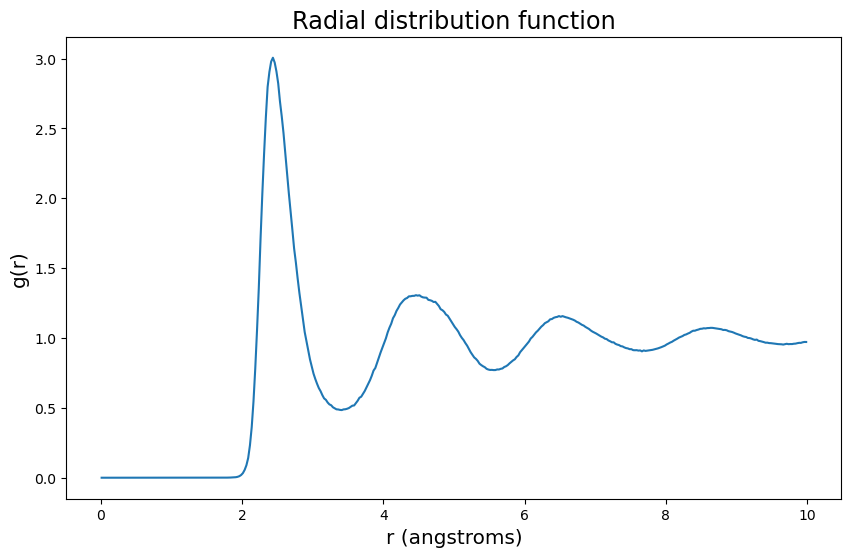

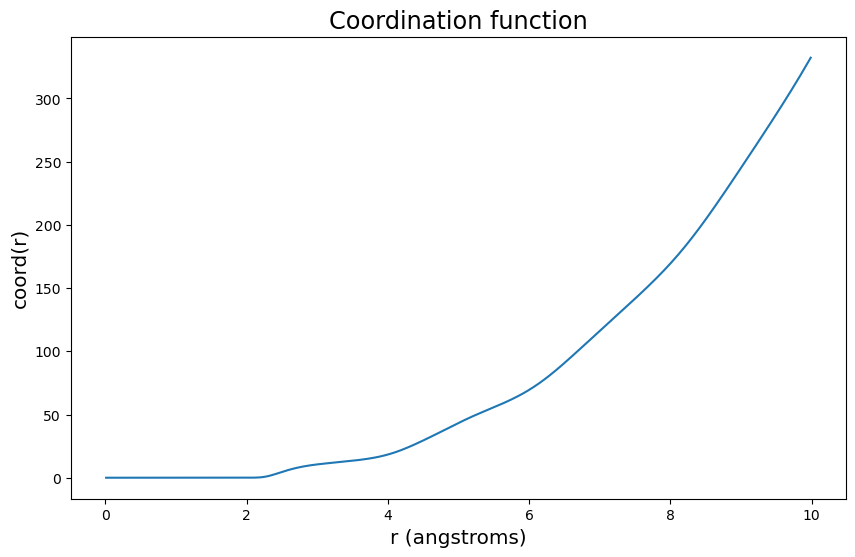

In [16]:
rdf = results_dict['rdf']
#rdf = am.thermo.RDF(lammps_rdf_file='rdf.txt')

fig = plt.figure(figsize=(10,6))
plt.title('Radial distribution function', size='xx-large')
plt.xlabel('r (angstroms)', size='x-large')
plt.ylabel('g(r)', size='x-large')
plt.plot(rdf.r, rdf.g)
plt.show()
    
fig = plt.figure(figsize=(10,6))
plt.title('Coordination function', size='xx-large')
plt.xlabel('r (angstroms)', size='x-large')
plt.ylabel('coord(r)', size='x-large')
plt.plot(rdf.r, rdf.coord)
plt.show()

### 4.3. Optional: Clean calculation files

The calculation may generate output files when it runs.  Calling calculation.clean_files() will delete any generated files to keep the workspace clean.

In [17]:
#calculation.clean_files()